<a href="https://colab.research.google.com/github/Faisaleka21/Machine_Learning/blob/main/jawaban_no4_ML-REGRESI-LINEAR-BERGANDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NO 4

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [36]:
# --- Memuat Data ---
df = pd.read_csv('https://raw.githubusercontent.com/Faisaleka21/Machine_Learning/refs/heads/main/data_set/LK1.csv',sep=';')
print(df.head())

  Nama  Berat  Usia Tinggi
0   A1     28     9    127
1   A2     45    15    160
2   A3     43    12    158
3   A4     15     6      ?
4   A5     65    18    167


In [37]:
# --- Mengubah Nama Kolom ---
# df.rename(columns={
#     'Number_of_Customers_Per_Day': 'Customers',
#     'Average_Order_Value': 'Avg_Order',
#     'Operating_Hours_Per_Day': 'Hours',
#     'Number_of_Employees': 'Employees',
#     'Marketing_Spend_Per_Day': 'Marketing',
#     'Location_Foot_Traffic': 'Foot_Traffic',
#     'Daily_Revenue': 'Revenue'
# }, inplace=True)

print(df.head())

  Nama  Berat  Usia Tinggi
0   A1     28     9    127
1   A2     45    15    160
2   A3     43    12    158
3   A4     15     6      ?
4   A5     65    18    167


In [38]:
# --- Eksplorasi Data ---
df.shape

(8, 4)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Nama    8 non-null      object
 1   Berat   8 non-null      int64 
 2   Usia    8 non-null      int64 
 3   Tinggi  8 non-null      object
dtypes: int64(2), object(2)
memory usage: 388.0+ bytes


In [40]:
df.isna().sum()

,0
Nama,0
Berat,0
Usia,0
Tinggi,0


In [41]:

# --- Menentukan Feature (X) dan Target (y) ---
# Menghapus kolom Revenue dari X karena itu yang mau diprediksi
x = df.drop(['Nama'], axis=1)
y = df['Tinggi']

In [42]:
# Menampilkan data X dan y
x
y

,Tinggi
0,127
1,160
2,158
3,?
4,167
5,163
6,142
7,?


In [43]:
df['Tinggi'] = df['Tinggi'].replace('?', None)
df['Tinggi'] = pd.to_numeric(df['Tinggi'])

# Ambil data latih (selain baris 4 & 8)
train_df = df.drop([3, 7])   # index mulai dari 0

# Data uji (baris 4 & 8)
test_df = df.iloc[[3, 7]]

# Tentukan fitur dan target
x_train = train_df[['Berat', 'Usia']]
y_train = train_df['Tinggi']

x_test = test_df[['Berat', 'Usia']]
y_test = test_df['Tinggi']

In [44]:
# --- Membuat dan Melatih Model ---
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [45]:
# --- Melakukan Prediksi ---
y_pred = model.predict(x_test)
print(y_pred)

[119.2277585  139.45912589]


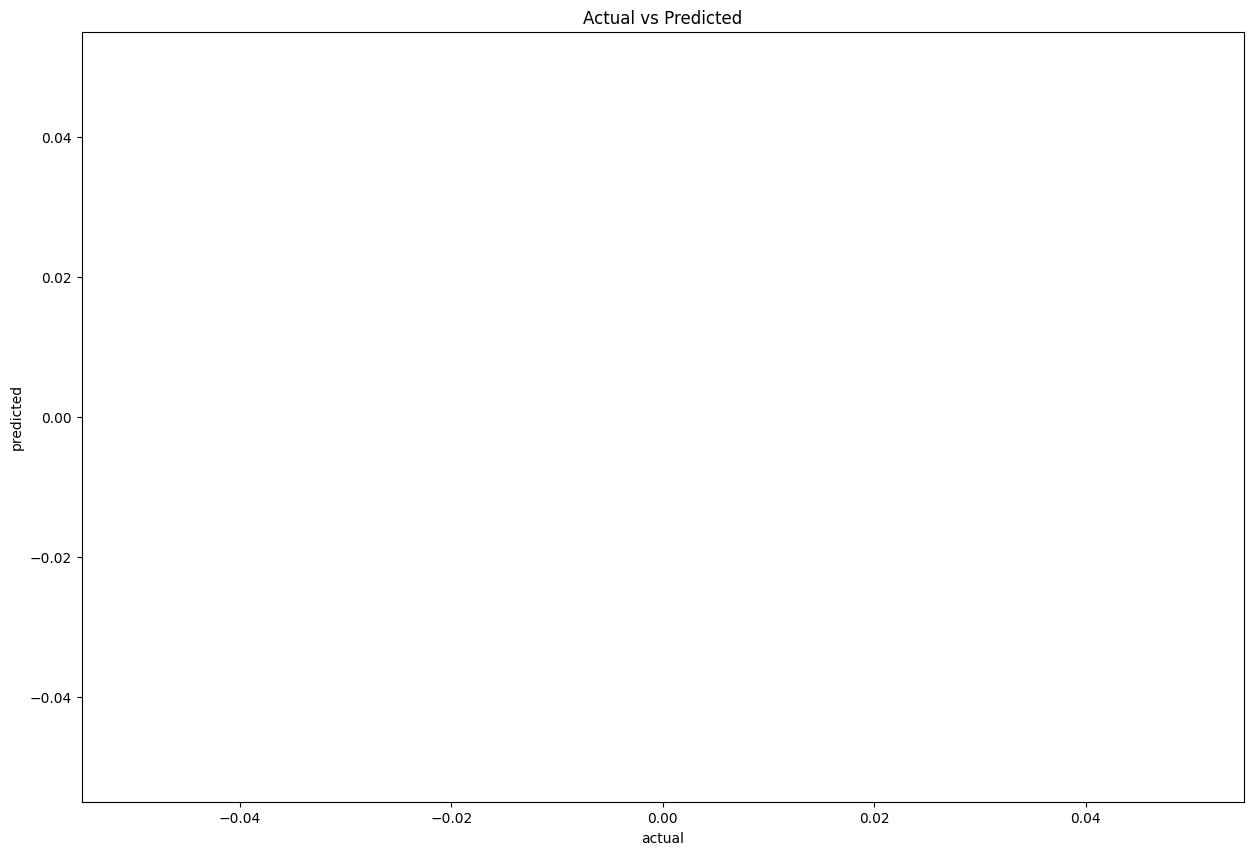

In [46]:
# --- Visualisasi Hasil ---
plt.figure(figsize=(15, 10))
plt.scatter(y_test, y_pred)
plt.xlabel('actual')
plt.ylabel('predicted')
plt.title('Actual vs Predicted')
plt.show()

In [47]:
# # --- Evaluasi Model ---
# mse = mean_squared_error(y_test, y_pred)
# rmse = np.sqrt(mean_squared_error(y_test, y_pred))
# mae = mean_absolute_error(y_test, y_pred)
# r2 = r2_score(y_test, y_pred)

# print('MSE = ', mse)
# print('RMSE = ', rmse)
# print('MAE = ', mae)
# print('R2 Score = ', r2)

In [48]:
# --- Melihat Koefisien dan Intercept ---
intercept = model.intercept_
coefficients = model.coef_

coef_df = pd.DataFrame({
    'Feature': x_train.columns,
    'Coefficient': coefficients
})

print(f'Intercept: {intercept:.4f}')
print('\nCoefficient:')
display(coef_df)

# --- Membuat String Rumus Regresi ---
rumus_regresi = f"y = {intercept:.4f} " + " ".join(
    [f"+ ({coef:.4f} * {feature})" for feature, coef in zip(x_train.columns, coefficients)]
)

print(f'\nRumus regresi: {rumus_regresi}')

Intercept: 98.6563

Coefficient:


,Feature,Coefficient
0,Berat,0.686326
1,Usia,1.712765



Rumus regresi: y = 98.6563 + (0.6863 * Berat) + (1.7128 * Usia)


In [49]:
# Prediksi langsung untuk data yang Tinggi-nya kosong
test_df = test_df.copy()

# Prediksi + pembulatan
test_df['Prediksi_Tinggi'] = y_pred.round().astype(int)

print(test_df[['Nama', 'Berat', 'Usia', 'Prediksi_Tinggi']])

  Nama  Berat  Usia  Prediksi_Tinggi
3   A4     15     6              119
7   A8     32    11              139


In [50]:
# --- Membuat Tabel Perbandingan Data Test ---
df2 = pd.DataFrame(x_test, columns=x.columns)
df2['Y Actual'] = y_test.values
df2['Y Predicted'] = y_pred
display(df2)

,Berat,Usia,Tinggi,Y Actual,Y Predicted
3,15,6,NaN,NaN,119.227759
7,32,11,NaN,NaN,139.459126


In [51]:
# --- Eksport Hasil ke Excel ---
df2.to_excel('Hasil NO 4.xlsx', index=False)